# Twitter Sentiment Analysis using RNN and LSTM
## Deep Learning Assignment - Text Classification

**Objective:** Compare the performance of Simple RNN and LSTM models for sentiment classification on Twitter data.

**Dataset:** Twitter sentiments about Borderlands game

**Classes:** Positive, Negative, Neutral

## Import Required Libraries

In [39]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0


## Stage 1: Data Loading and Exploration

In [40]:
# Load the dataset
df = pd.read_csv(r'C:\Users\syari\Downloads\twitter_sentiments.csv')

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!

Dataset shape: (12447, 4)

First few rows:


,ID,entity,sentiment,content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2402,Borderlands,Positive,So I spent a few hours making something for fu...
2,2403,Borderlands,Neutral,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."
3,2404,Borderlands,Positive,that was the first borderlands session in a lo...
4,2405,Borderlands,Negative,the biggest dissappoinment in my life came out...


In [41]:
# Check dataset information
print("Dataset Information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDataset statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12447 entries, 0 to 12446
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         12447 non-null  int64 
 1   entity     12447 non-null  object
 2   sentiment  12447 non-null  object
 3   content    12447 non-null  object
dtypes: int64(1), object(3)
memory usage: 389.1+ KB
None

Missing values:
ID           0
entity       0
sentiment    0
content      0
dtype: int64

Dataset statistics:
                 ID
count  12447.000000
mean    6432.586165
std     3740.553090
min        1.000000
25%     3195.500000
50%     6422.000000
75%     9600.500000
max    13200.000000


In [42]:
# Check class distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nPercentage Distribution:")
print(df['sentiment'].value_counts(normalize=True) * 100)

Sentiment Distribution:
sentiment
Negative      3757
Positive      3472
Neutral       3053
Irrelevant    2165
Name: count, dtype: int64

Percentage Distribution:
sentiment
Negative      30.183980
Positive      27.894272
Neutral       24.527999
Irrelevant    17.393749
Name: proportion, dtype: float64


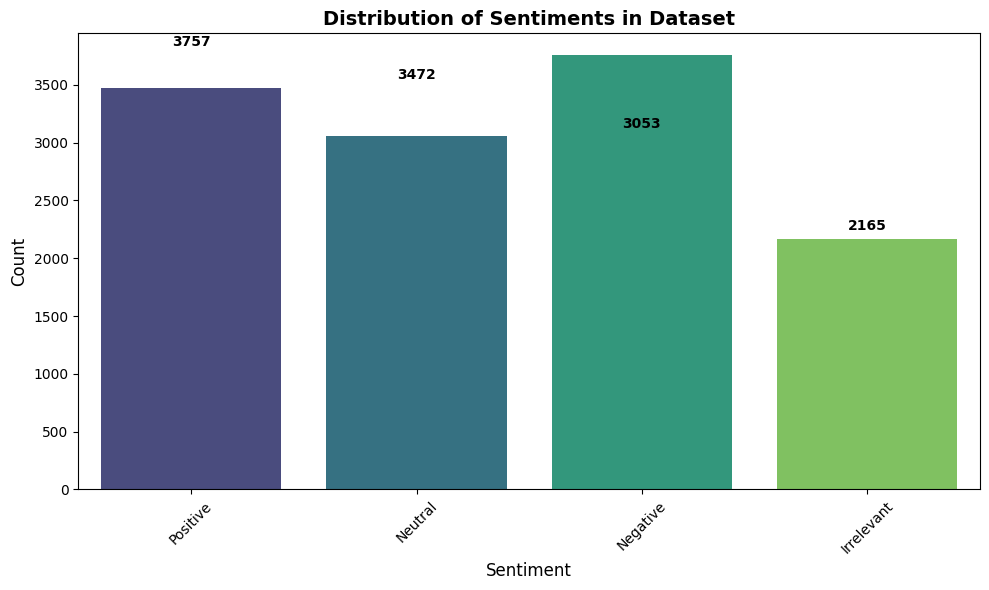

In [43]:
# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Distribution of Sentiments in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(df['sentiment'].value_counts().values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 2: Data Preprocessing

### 2.1 Text Cleaning

In [44]:
def clean_text(text):
    """
    Clean text data by:
    1. Removing URLs
    2. Removing mentions (@username)
    3. Removing special characters and punctuation
    4. Converting to lowercase
    5. Removing extra whitespaces
    """
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (#hashtag)
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespaces
    text = ' '.join(text.split())
    
    return text

# Apply text cleaning
print("Cleaning text data...")
df['cleaned_content'] = df['content'].apply(clean_text)

# Display examples
print("\nExample of text cleaning:")
for i in range(3):
    print(f"\nOriginal: {df['content'].iloc[i]}")
    print(f"Cleaned: {df['cleaned_content'].iloc[i]}")

Cleaning text data...

Example of text cleaning:

Original: im getting on borderlands and i will murder you all ,
Cleaned: im getting on borderlands and i will murder you all

Original: So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy! pic.twitter.com/mLsI5wf9Jg
Cleaned: so i spent a few hours making something for fun if you dont know i am a huge fan and maya is one of my favorite characters so i decided to make myself a wallpaper for my pc here is the original image versus the creation i made enjoy pictwittercommlsiwfjg

Original: Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it/RMTrgF  
Cleaned: rockhard la varlope rare powerful handsome jackpot borderlands xbox dlvritrmtrgf


In [45]:
# Remove empty texts after cleaning
df = df[df['cleaned_content'].str.len() > 0]
print(f"Dataset shape after removing empty texts: {df.shape}")

Dataset shape after removing empty texts: (12227, 5)


### 2.2 Filter Relevant Sentiments

We'll focus on Positive, Negative, and Neutral sentiments only.

In [46]:
# Filter only Positive, Negative, and Neutral sentiments
valid_sentiments = ['Positive', 'Negative', 'Neutral']
df = df[df['sentiment'].isin(valid_sentiments)]

print(f"Dataset shape after filtering: {df.shape}")
print(f"\nSentiment distribution after filtering:")
print(df['sentiment'].value_counts())

Dataset shape after filtering: (10104, 5)

Sentiment distribution after filtering:
sentiment
Negative    3696
Positive    3428
Neutral     2980
Name: count, dtype: int64


### 2.3 Label Encoding (One-Hot Encoding)

In [47]:
# Encode labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['sentiment'])

# Convert to one-hot encoding
num_classes = len(label_encoder.classes_)
labels_one_hot = to_categorical(df['label_encoded'], num_classes=num_classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")
print(f"\nLabel encoding mapping:")
for i, sentiment in enumerate(label_encoder.classes_):
    print(f"{sentiment}: {i}")

print(f"\nOne-hot encoding shape: {labels_one_hot.shape}")
print(f"Example one-hot encoding:")
print(f"Sentiment: {df['sentiment'].iloc[0]} -> {labels_one_hot[0]}")

Number of classes: 3
Classes: ['Negative' 'Neutral' 'Positive']

Label encoding mapping:
Negative: 0
Neutral: 1
Positive: 2

One-hot encoding shape: (10104, 3)
Example one-hot encoding:
Sentiment: Positive -> [0. 0. 1.]


### 2.4 Tokenization and Padding

In [48]:
# Tokenization parameters
MAX_WORDS = 10000  # Maximum number of words in vocabulary
MAX_SEQUENCE_LENGTH = 100  # Maximum length of each sequence

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_content'])

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_content'])

# Pad sequences to uniform length
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Number of sequences: {len(sequences)}")
print(f"Padded sequences shape: {X.shape}")

# Display example
print(f"\nExample tokenization:")
print(f"Original text: {df['cleaned_content'].iloc[0]}")
print(f"Tokenized sequence: {sequences[0][:20]}...")  # Show first 20 tokens
print(f"Padded sequence shape: {X[0].shape}")

Vocabulary size: 16952
Number of sequences: 10104
Padded sequences shape: (10104, 100)

Example tokenization:
Original text: im getting on borderlands and i will murder you all
Tokenized sequence: [22, 115, 14, 108, 5, 3, 64, 1519, 15, 30]...
Padded sequence shape: (100,)


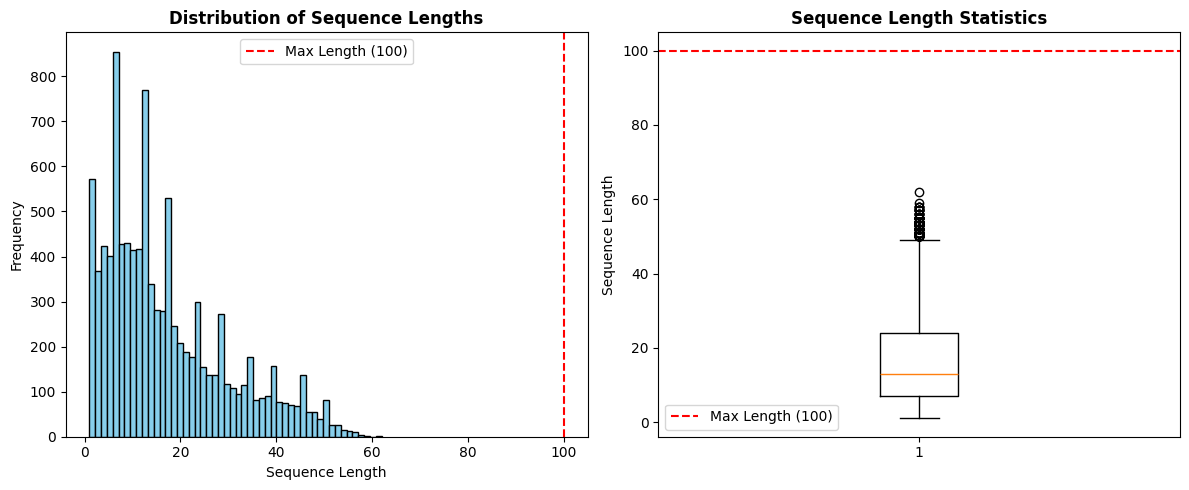


Sequence length statistics:
Mean: 17.08
Median: 13.00
Min: 1
Max: 62
Percentage of sequences longer than 100: 0.00%


In [49]:
# Analyze sequence lengths
sequence_lengths = [len(seq) for seq in sequences]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(sequence_lengths, bins=50, color='skyblue', edgecolor='black')
plt.axvline(MAX_SEQUENCE_LENGTH, color='red', linestyle='--', label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
plt.title('Distribution of Sequence Lengths', fontweight='bold')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(sequence_lengths, vert=True)
plt.axhline(MAX_SEQUENCE_LENGTH, color='red', linestyle='--', label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
plt.title('Sequence Length Statistics', fontweight='bold')
plt.ylabel('Sequence Length')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nSequence length statistics:")
print(f"Mean: {np.mean(sequence_lengths):.2f}")
print(f"Median: {np.median(sequence_lengths):.2f}")
print(f"Min: {np.min(sequence_lengths)}")
print(f"Max: {np.max(sequence_lengths)}")
print(f"Percentage of sequences longer than {MAX_SEQUENCE_LENGTH}: {(np.array(sequence_lengths) > MAX_SEQUENCE_LENGTH).sum() / len(sequence_lengths) * 100:.2f}%")

### 2.5 Train-Test Split

In [50]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, labels_one_hot, test_size=0.2, random_state=42, stratify=df['sentiment']
)

print("Data split completed!")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Data split completed!

Training set size: 8083 samples
Testing set size: 2021 samples

Training set shape: (8083, 100)
Testing set shape: (2021, 100)

Training labels shape: (8083, 3)
Testing labels shape: (2021, 3)


## Stage 3: Model Architecture and Training

### 3.1 Model 1 - Simple RNN

In [51]:
# Model hyperparameters
EMBEDDING_DIM = 128
RNN_UNITS = 64
DROPOUT_RATE = 0.5
BATCH_SIZE = 32
EPOCHS = 50

# Build Simple RNN model
print("Building Simple RNN Model...")
rnn_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    SimpleRNN(units=RNN_UNITS, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(num_classes, activation='softmax')
])

# Compile the model
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\nRNN Model Architecture:")
rnn_model.summary()

Building Simple RNN Model...

RNN Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the RNN model
print("Training Simple RNN Model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

print("\nRNN Model training completed!")

Training Simple RNN Model...
Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3457 - loss: 1.1070 - val_accuracy: 0.3647 - val_loss: 1.0946
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3604 - loss: 1.1005 - val_accuracy: 0.3637 - val_loss: 1.0948
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3576 - loss: 1.1094 - val_accuracy: 0.3528 - val_loss: 1.0980
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3555 - loss: 1.1031 - val_accuracy: 0.3657 - val_loss: 1.0939
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3671 - loss: 1.0967 - val_accuracy: 0.3667 - val_loss: 1.0925
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3613 - loss: 1.1031 - val_accuracy: 0.3657 - val_loss: 1.0952
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3555 - loss: 1.0987 - val_accuracy: 0.3622 - val_loss: 1.0952
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3

### 3.2 Model 2 - LSTM

In [53]:
# Build LSTM model
print("Building LSTM Model...")
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(units=RNN_UNITS, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\nLSTM Model Architecture:")
lstm_model.summary()

Building LSTM Model...

LSTM Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Train the LSTM model
print("Training LSTM Model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

print("\nLSTM Model training completed!")

Training LSTM Model...
Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.3444 - loss: 1.0989 - val_accuracy: 0.3657 - val_loss: 1.0952
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.3603 - loss: 1.0970 - val_accuracy: 0.3657 - val_loss: 1.0948
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.3560 - loss: 1.0970 - val_accuracy: 0.3657 - val_loss: 1.0949
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.3549 - loss: 1.0966 - val_accuracy: 0.3657 - val_loss: 1.0950
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.3617 - loss: 1.0966 - val_accuracy: 0.3657 - val_loss: 1.0949
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.3647 - loss: 1.0965 - val_accuracy: 0.3657 - val_loss: 1.0949
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.3564 - loss: 1.0970 - val_accuracy: 0.3657 - val_loss: 1.0948
Epoch 7: early stopping
Restoring model weights from the end of the best 

### 3.3 Training History Visualization

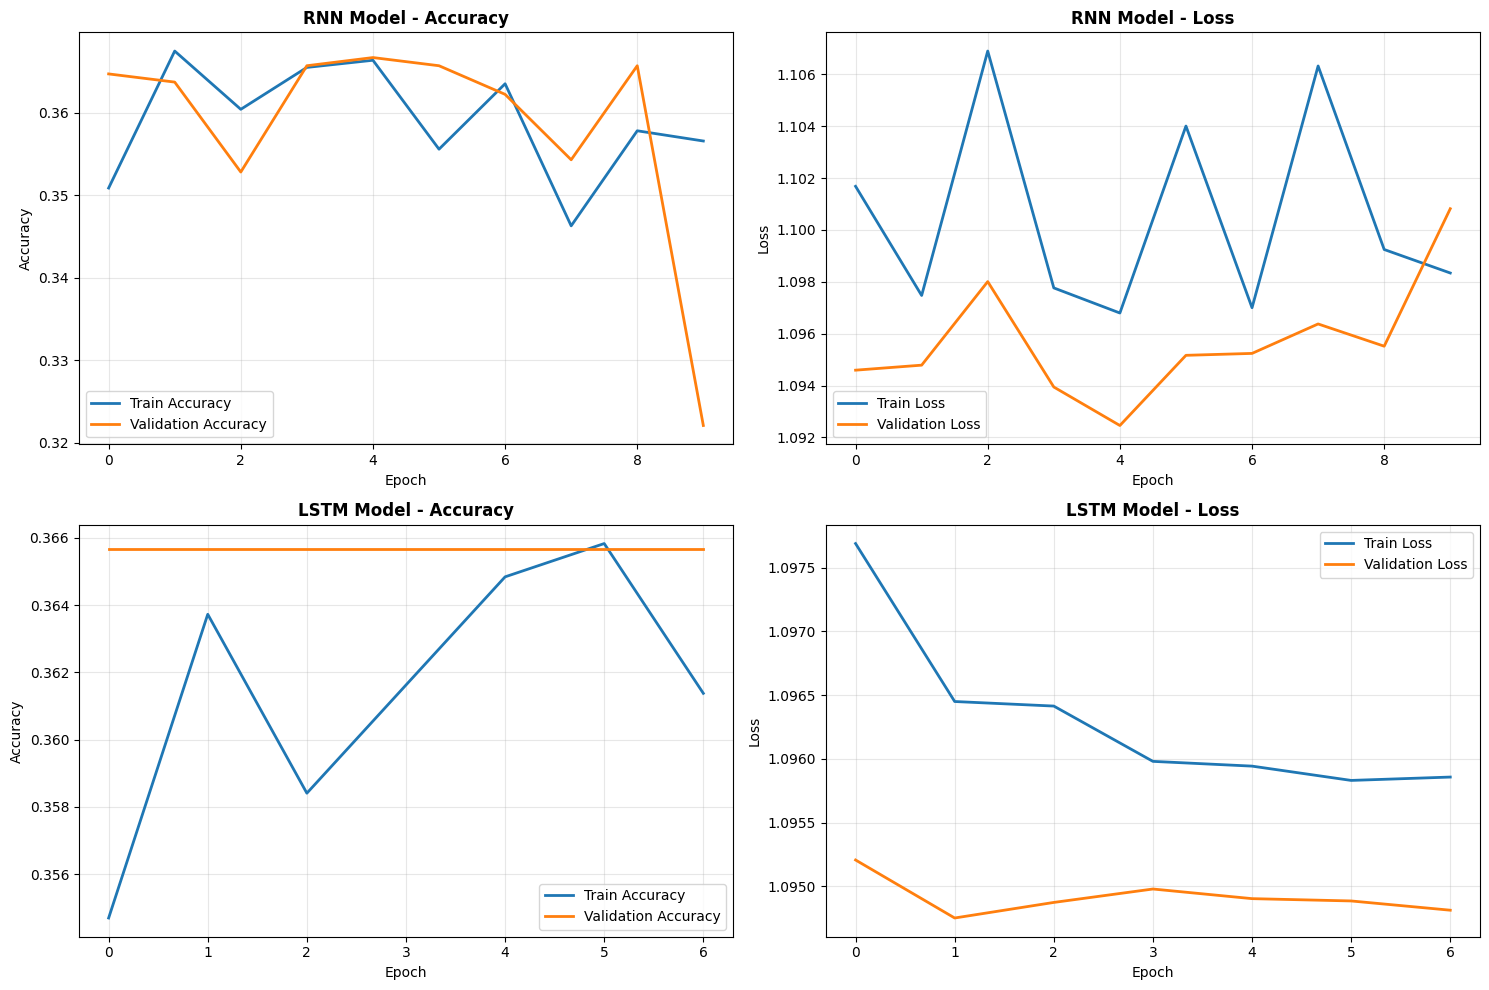

Training history plots saved!


In [55]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RNN - Accuracy
axes[0, 0].plot(rnn_history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(rnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('RNN Model - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RNN - Loss
axes[0, 1].plot(rnn_history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(rnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('RNN Model - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# LSTM - Accuracy
axes[1, 0].plot(lstm_history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1, 0].plot(lstm_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1, 0].set_title('LSTM Model - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# LSTM - Loss
axes[1, 1].plot(lstm_history.history['loss'], label='Train Loss', linewidth=2)
axes[1, 1].plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1, 1].set_title('LSTM Model - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\syari\Downloads\training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plots saved!")

## Stage 4: Model Evaluation and Analysis

### 4.1 Make Predictions

In [56]:
# Make predictions
print("Making predictions...")

# RNN predictions
rnn_pred_probs = rnn_model.predict(X_test)
rnn_predictions = np.argmax(rnn_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# LSTM predictions
lstm_pred_probs = lstm_model.predict(X_test)
lstm_predictions = np.argmax(lstm_pred_probs, axis=1)

print("Predictions completed!")

Making predictions...
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Predictions completed!


### 4.2 Calculate Metrics (Accuracy, Precision, Recall, F1-Score)

In [57]:
def calculate_metrics(y_true, y_pred, model_name):
    """
    Calculate evaluation metrics for a model
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'='*50}")
    print(f"{model_name} Model Evaluation Metrics")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

# Calculate metrics for both models
rnn_metrics = calculate_metrics(y_test_labels, rnn_predictions, "RNN")
lstm_metrics = calculate_metrics(y_test_labels, lstm_predictions, "LSTM")


RNN Model Evaluation Metrics
Accuracy:  0.3667 (36.67%)
Precision: 0.5419 (54.19%)
Recall:    0.3667 (36.67%)
F1-Score:  0.1998 (19.98%)

LSTM Model Evaluation Metrics
Accuracy:  0.3657 (36.57%)
Precision: 0.1337 (13.37%)
Recall:    0.3657 (36.57%)
F1-Score:  0.1958 (19.58%)


In [58]:
# Detailed classification report
print("\n" + "="*50)
print("RNN Model - Detailed Classification Report")
print("="*50)
print(classification_report(y_test_labels, rnn_predictions, 
                          target_names=label_encoder.classes_))

print("\n" + "="*50)
print("LSTM Model - Detailed Classification Report")
print("="*50)
print(classification_report(y_test_labels, lstm_predictions, 
                          target_names=label_encoder.classes_))


RNN Model - Detailed Classification Report
              precision    recall  f1-score   support

    Negative       0.37      1.00      0.54       739
     Neutral       1.00      0.00      0.01       596
    Positive       0.33      0.00      0.01       686

    accuracy                           0.37      2021
   macro avg       0.57      0.33      0.18      2021
weighted avg       0.54      0.37      0.20      2021


LSTM Model - Detailed Classification Report
              precision    recall  f1-score   support

    Negative       0.37      1.00      0.54       739
     Neutral       0.00      0.00      0.00       596
    Positive       0.00      0.00      0.00       686

    accuracy                           0.37      2021
   macro avg       0.12      0.33      0.18      2021
weighted avg       0.13      0.37      0.20      2021



### 4.3 Confusion Matrix Visualization

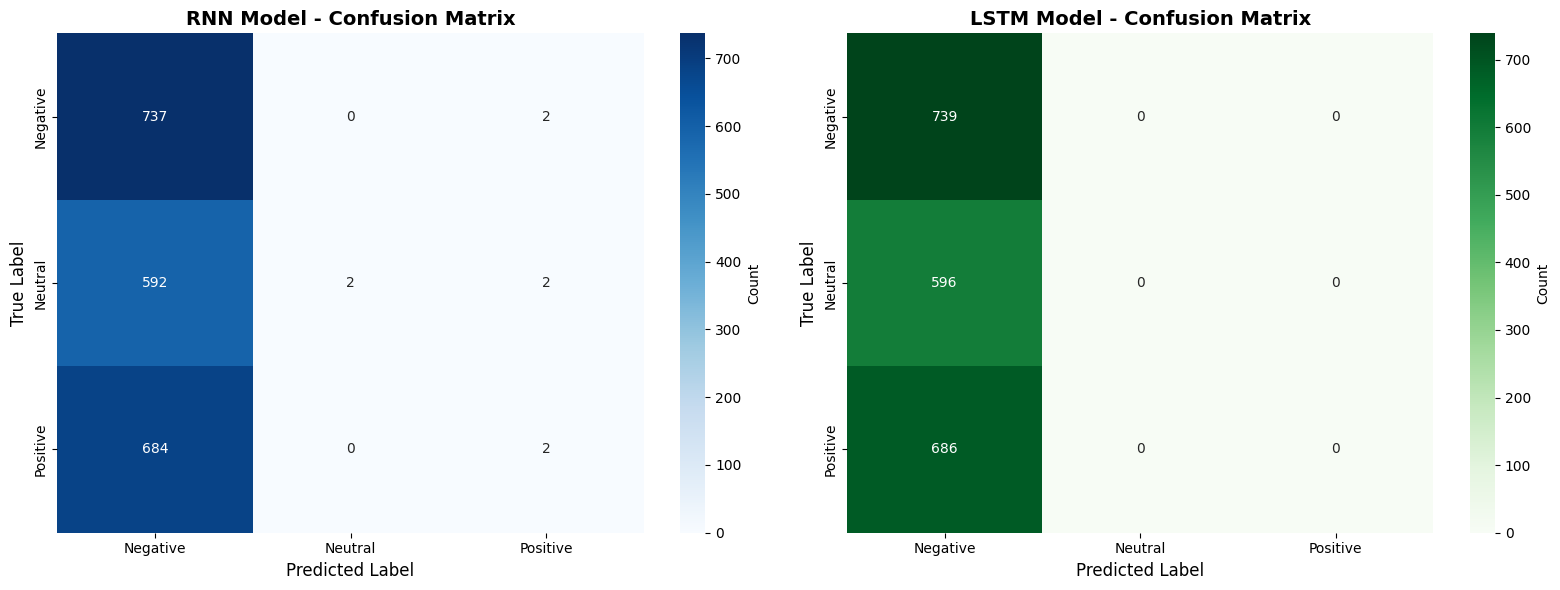

Confusion matrices saved!


In [59]:
# Generate confusion matrices
rnn_cm = confusion_matrix(y_test_labels, rnn_predictions)
lstm_cm = confusion_matrix(y_test_labels, lstm_predictions)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RNN Confusion Matrix
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('RNN Model - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# LSTM Confusion Matrix
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('LSTM Model - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\syari\Downloads\confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved!")

### 4.4 Model Comparison Visualization

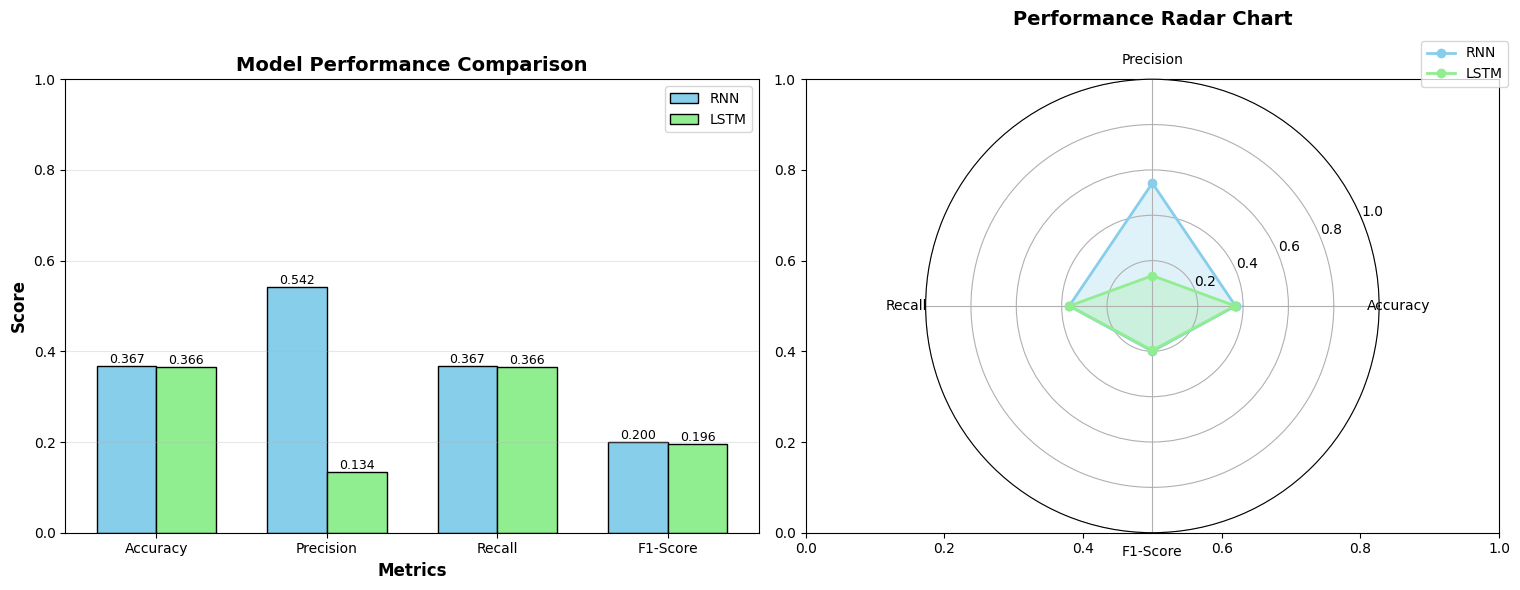

Model comparison plots saved!


In [60]:
# Prepare comparison data
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rnn_values = [rnn_metrics['accuracy'], rnn_metrics['precision'], 
              rnn_metrics['recall'], rnn_metrics['f1_score']]
lstm_values = [lstm_metrics['accuracy'], lstm_metrics['precision'], 
               lstm_metrics['recall'], lstm_metrics['f1_score']]

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, rnn_values, width, label='RNN', color='skyblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, lstm_values, width, label='LSTM', color='lightgreen', edgecolor='black')

axes[0].set_xlabel('Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

# Radar chart comparison
angles = np.linspace(0, 2 * np.pi, len(metrics_names), endpoint=False).tolist()
rnn_values_radar = rnn_values + [rnn_values[0]]
lstm_values_radar = lstm_values + [lstm_values[0]]
angles += angles[:1]

ax = plt.subplot(122, projection='polar')
ax.plot(angles, rnn_values_radar, 'o-', linewidth=2, label='RNN', color='skyblue')
ax.fill(angles, rnn_values_radar, alpha=0.25, color='skyblue')
ax.plot(angles, lstm_values_radar, 'o-', linewidth=2, label='LSTM', color='lightgreen')
ax.fill(angles, lstm_values_radar, alpha=0.25, color='lightgreen')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1)
ax.set_title('Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig(r'C:\Users\syari\Downloads\model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison plots saved!")